In [31]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

C:\Users\HP\myenv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [32]:
train_df = pd.read_csv('Train.csv')
test_df  = pd.read_csv('Test.csv')

print(train_df.shape)
print(train_df.head())
print(train_df['Label'].value_counts())

(1619, 2)
               Image_id  Label
0  id_02amazy34fgh2.jpg      1
1  id_02mh3w48pmyc9.jpg      0
2  id_02rpb463h9d3w.jpg      0
3  id_02wc3jeeao8ol.jpg      1
4  id_03t2hapb8wz8p.jpg      1
Label
0    810
1    809
Name: count, dtype: int64


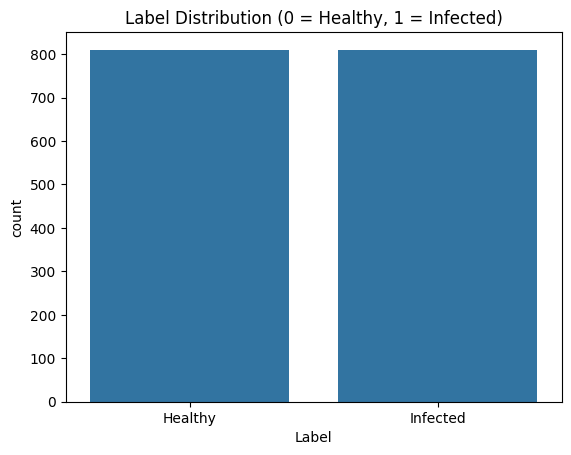

In [33]:
sns.countplot(x='Label', data=train_df)
plt.title('Label Distribution (0 = Healthy, 1 = Infected)')
plt.xticks([0, 1], ['Healthy', 'Infected'])
plt.show()

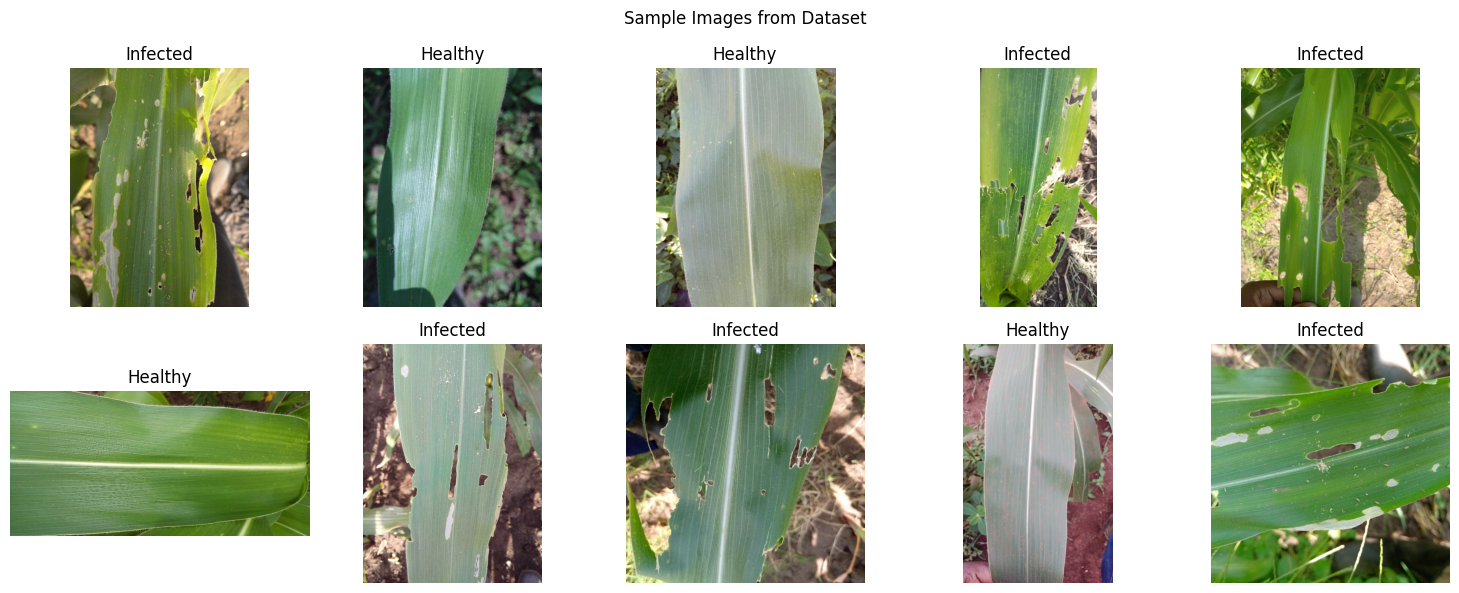

In [34]:
IMG_DIR = 'Images/'

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    row = train_df.iloc[i]
    img = Image.open(os.path.join(IMG_DIR, row['Image_id']))
    ax.imshow(img)
    ax.set_title('Infected' if row['Label'] == 1 else 'Healthy')
    ax.axis('off')
plt.suptitle('Sample Images from Dataset')
plt.tight_layout()
plt.show()

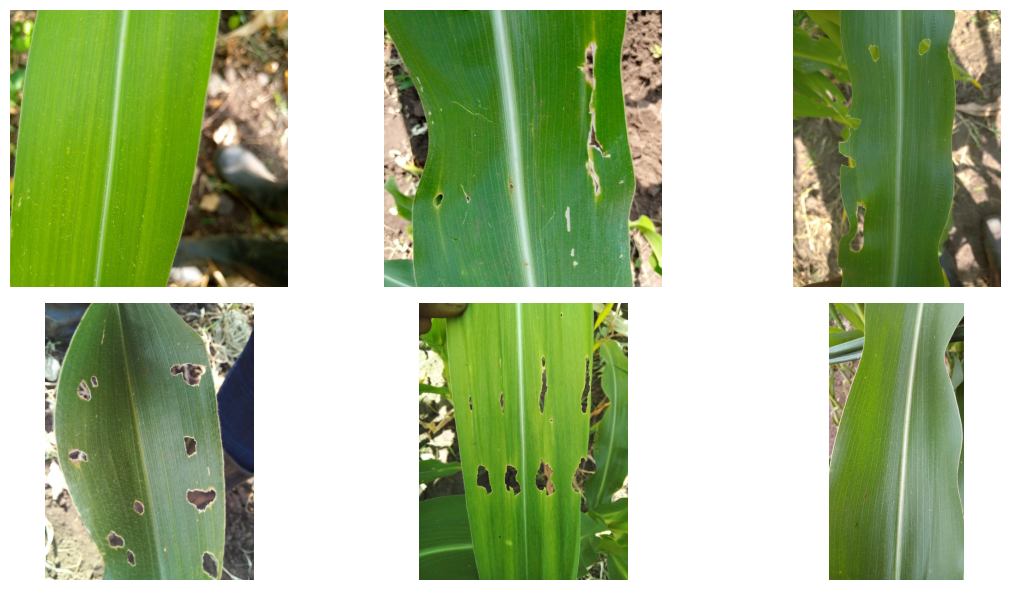

In [20]:
image_files = os.listdir('images')

sample_images = random.sample(image_files, 6)

plt.figure(figsize=(12,6))

for i, img_name in enumerate(sample_images):
    
    img_path = os.path.join('images', img_name)
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.show()

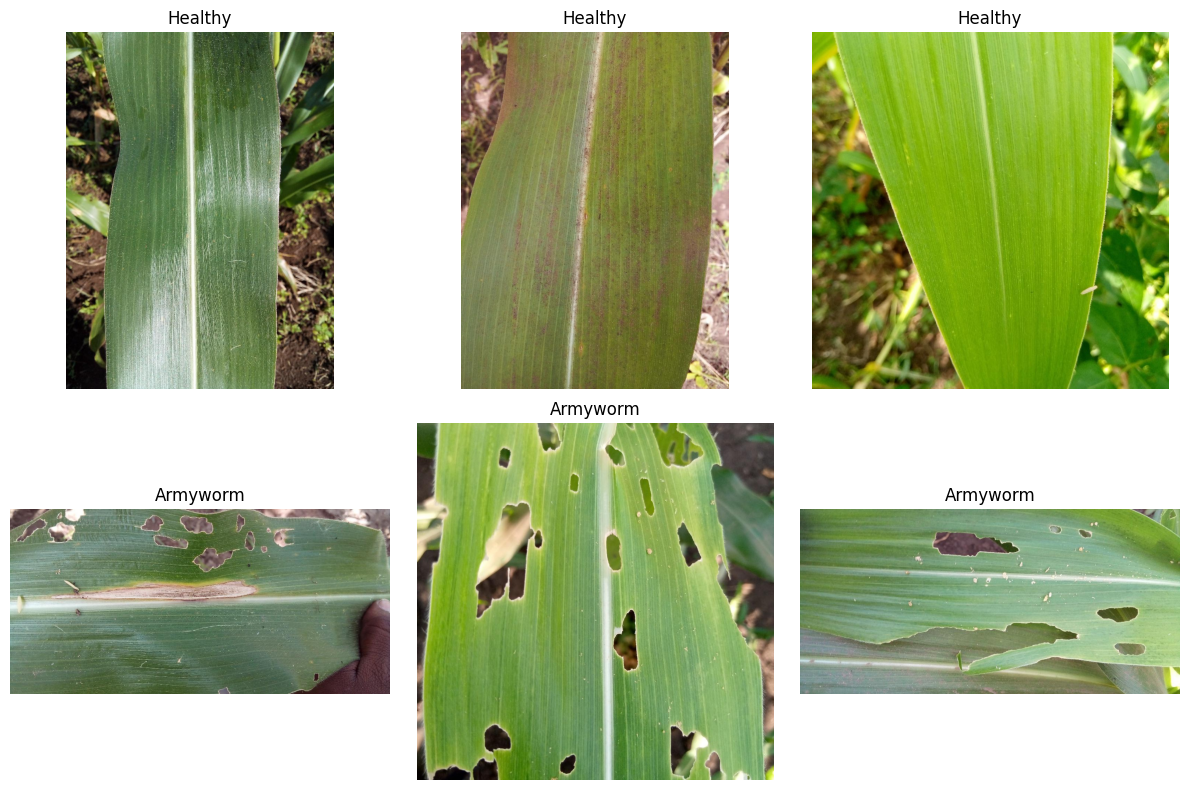

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(12,8))

healthy = train_df[train_df["Label"] == 0].sample(3)
affected = train_df[train_df["Label"] == 1].sample(3)

for i, (_, row) in enumerate(healthy.iterrows()):
    img = cv2.imread(row["image_path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[0, i].imshow(img)
    axes[0, i].set_title("Healthy")
    axes[0, i].axis("off")

for i, (_, row) in enumerate(affected.iterrows()):
    img = cv2.imread(row["image_path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[1, i].imshow(img)
    axes[1, i].set_title("Armyworm")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [35]:
IMG_SIZE = (128, 128)

def load_image(image_id):
    path = os.path.join(IMG_DIR, image_id)
    img = load_img(path, target_size=IMG_SIZE)
    return img_to_array(img) / 255.0

X, y = [], []
for _, row in train_df.iterrows():
    X.append(load_image(row['Image_id']))
    y.append(row['Label'])

X = np.array(X)
y = np.array(y)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (1619, 128, 128, 3)
y shape: (1619,)


In [36]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} | Validation: {X_val.shape[0]}")

Train: 1295 | Validation: 324


In [37]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

C:\Users\HP\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 316ms/step - accuracy: 0.9753 - loss: 0.0777 - val_accuracy: 0.8642 - val_loss: 0.3636
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 305ms/step - accuracy: 0.9714 - loss: 0.0826 - val_accuracy: 0.8858 - val_loss: 0.3583
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 305ms/step - accuracy: 0.9846 - loss: 0.0469 - val_accuracy: 0.9074 - val_loss: 0.3449
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 306ms/step - accuracy: 0.9907 - loss: 0.0339 - val_accuracy: 0.8858 - val_loss: 0.4074
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 318ms/step - accuracy: 0.9892 - loss: 0.0326 - val_accuracy: 0.9012 - val_loss: 0.3852
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 15s 364ms/step - accuracy: 0.9900 - loss: 0.0398 - val_accuracy: 0.8981 - val_loss: 0.4896
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 315ms/step - accuracy: 0.9907 - loss: 0.0289 - val_accuracy: 0.8827 - val_loss: 0.5063
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 323ms/step - accuracy: 0.9977 - loss: 0.0117 - val_accu

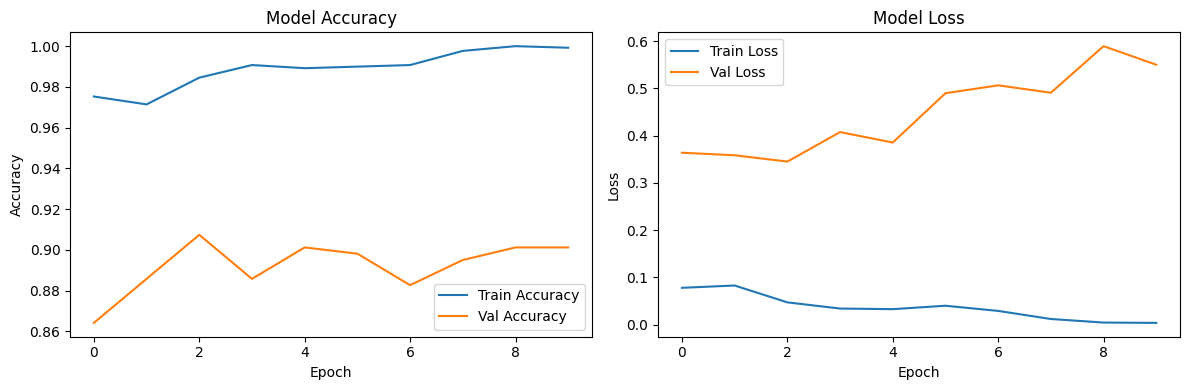

In [40]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [41]:
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")
print(f"Validation Loss: {loss:.4f}")

y_pred = (model.predict(X_val) > 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=['Healthy', 'Infected']))

Validation Accuracy: 90.12%
Validation Loss: 0.5500
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.89      0.91      0.90       162
    Infected       0.91      0.89      0.90       162

    accuracy                           0.90       324
   macro avg       0.90      0.90      0.90       324
weighted avg       0.90      0.90      0.90       324



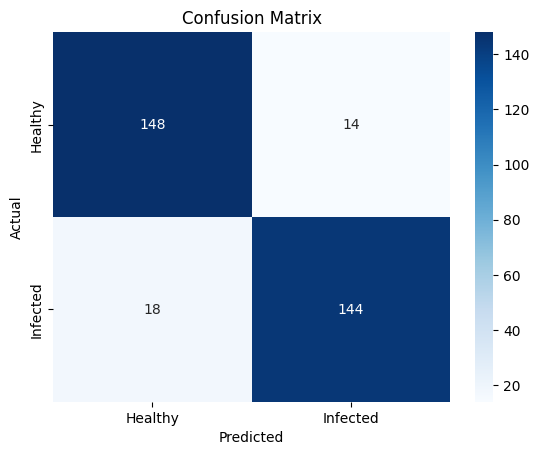

In [42]:
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Infected'],
            yticklabels=['Healthy', 'Infected'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [43]:
model.save('armyworm_model.h5')
print("Model saved.")

Model saved.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


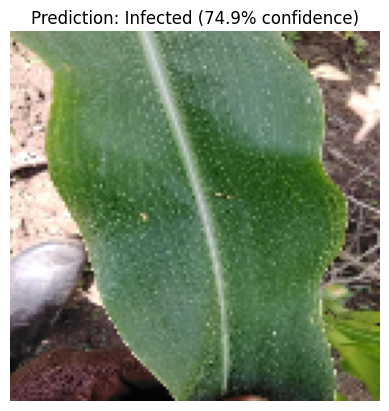

In [59]:
def predict_image(image_path):
    img = load_img(image_path, target_size=IMG_SIZE)
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]
    label = 'Infected' if prediction > 0.5 else 'Healthy'
    confidence = prediction if prediction > 0.5 else 1 - prediction

    plt.imshow(img)
    plt.title(f"Prediction: {label} ({confidence * 100:.1f}% confidence)")
    plt.axis('off')
    plt.show()

# Usage — just change the filename
predict_image('Images/id_0unlhj59tv0p4.jpg')

